# CNN-LSTM (IMU-Only, PyTorch)
## Gym Exercise Activity Recognition


Adapted to **Scenario III** (accelerometer + gyroscope only), which achieved **96.96% accuracy** and **91.78% F1-score** on the Gym Exercise dataset.

### Architecture (Figure 5)
```
<!-- Input (window_size × C channels)
  → [Conv1D → BatchNorm → ReLU → MaxPool1D → Dropout] × 4
  → ResBiGRU (2 stacked BiGRU layers with residual + LayerNorm)
  → Global Average Pooling
  → Dense(128, ReLU) → Dropout(0.5)
  → Dense(num_classes)
``` -->

---
## 0. Setup & Configuration

In [116]:
# Uncomment to install dependencies if needed:
!pip install torch scikit-learn scipy numpy pandas

In [117]:
import numpy as np
import torch
import torch.nn as nn
import os

from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import warnings
warnings.filterwarnings("ignore")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {DEVICE}")

PyTorch: 2.10.0
CUDA:    False
Device:  cpu


In [118]:
# ============================================================
# CONFIGURATION — edit these to match your setup
# ============================================================
SAMPLING_RATE    = 20       # Hz — your IMU's sampling frequency
NUM_IMU_CHANNELS = 6        # 6=accel+gyro, 3=accel only, 9=+magnetometer
NUM_CLASSES      = 2        # number of exercises you're classifying
WINDOW_SIZE_SEC  = 2.0      # seconds per window
OVERLAP          = 0.5      # 50% overlap between windows
EPOCHS           = 50      # max training epochs
BATCH_SIZE       = 32
N_FOLDS          = 5        # used only in the optional comparison section
LEARNING_RATE    = 1e-3
PATIENCE         = 100      # early stopping patience


---
## 1. Data Preprocessing (Section 3.3)

In [119]:
class IMUPreprocessor:
    """
    Preprocessing pipeline for IMU-only data.

    Steps (Section 3.3):
      1. Denoising   — 6th-order zero-phase Butterworth bandpass (1–20 Hz)
      2. Normalize    — Per-channel min–max scaling to [0, 1]
      3. Segment      — Sliding window with overlap + majority-vote labels
    """

    def __init__(self, sampling_rate=50, window_size_sec=2.0, overlap=0.5,
                 imu_lowcut=1.0, imu_highcut=20.0, filter_order=6):
        self.fs = sampling_rate
        self.window_size = int(window_size_sec * sampling_rate)
        self.step_size = int(self.window_size * (1.0 - overlap))
        self.lowcut = imu_lowcut
        self.highcut = imu_highcut
        self.filter_order = filter_order

    # ----- 3.3.1 Denoising -----
    def denoise(self, data):
        """6th-order zero-phase Butterworth bandpass, per channel (1–20 Hz)."""
        nyq = 0.5 * self.fs
        lo = self.lowcut / nyq
        hi = min(self.highcut / nyq, 0.99)
        if lo <= 0 or lo >= hi:
            return data.copy()
        b, a = butter(self.filter_order, [lo, hi], btype="band")
        out = np.zeros_like(data, dtype=np.float64)
        min_len = 3 * max(len(b), len(a))
        for ch in range(data.shape[1]):
            if data.shape[0] > min_len:
                out[:, ch] = filtfilt(b, a, data[:, ch])
            else:
                out[:, ch] = data[:, ch]
        return out

    # ----- 3.3.2 Normalization -----
    def fit_normalize(self, data):
        """Fit per-channel min/max, return normalized data."""
        self._min = data.min(axis=0)
        self._max = data.max(axis=0)
        return self._apply_norm(data)

    def transform_normalize(self, data):
        """Apply previously fitted min–max (for test/inference)."""
        return np.clip(self._apply_norm(data), 0.0, 1.0)

    def _apply_norm(self, data):
        denom = self._max - self._min
        denom[denom == 0] = 1.0
        return ((data - self._min) / denom).astype(np.float32)

    # ----- 3.3.3 Sliding-window segmentation -----
    def segment(self, data, labels):
        """Sliding window with majority-vote labeling."""
        X, y = [], []
        T = data.shape[0]
        for s in range(0, T - self.window_size + 1, self.step_size):
            window = data[s : s + self.window_size]
            wlabels = labels[s : s + self.window_size]
            vals, cnts = np.unique(wlabels, return_counts=True)
            
            # Determine the majority vote
            majority_label = vals[cnts.argmax()] #-1
            
            # Only append if the label is not 0
            if majority_label != -1:
                X.append(window)
                y.append(majority_label)
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

    # ----- Full pipeline -----
    def preprocess(self, imu_data, labels):
        """Denoise → normalize → segment."""
        denoised = self.denoise(imu_data)
        normalized = self.fit_normalize(denoised)
        segment = self.segment(normalized, labels)
        print(segment[1].shape)
        return segment

---
## 2. Model Architecture (Section 3.4)

In [120]:
class ResBiGRUBlock(nn.Module):
    """
    Residual Bidirectional GRU block (Section 3.4.2, Figure 6, Eqs. 4-6).

    Each stacked layer:
        h = BiGRU(x)           # forward + backward GRU, concatenated
        r = Linear(x)          # project input to match h's dimension
        x = LayerNorm(r + h)   # residual connection + normalization
    """

    def __init__(self, input_dim, hidden=128, n_layers=2):
        super().__init__()
        self.blocks = nn.ModuleList()
        dim = input_dim
        for _ in range(n_layers):
            self.blocks.append(nn.ModuleDict({
                "gru":  nn.GRU(dim, hidden, batch_first=True, bidirectional=True),
                "proj": nn.Linear(dim, hidden * 2, bias=False),
                "ln":   nn.LayerNorm(hidden * 2),
            }))
            dim = hidden * 2  # BiGRU output: 2 * hidden

    def forward(self, x):
        for blk in self.blocks:
            h, _ = blk["gru"](x)       # (B, T, 2*hidden)
            r = blk["proj"](x)         # (B, T, 2*hidden)
            x = blk["ln"](r + h)       # residual + LayerNorm
        return x

In [121]:
class CNNResBiGRU(nn.Module):
    """
    CNN-ResBiGRU model (Section 3.4, Figure 5).

    Input:  (batch, seq_len, in_channels)
    Output: (batch, num_classes) — raw logits (use CrossEntropyLoss)
    """

    def __init__(self, in_channels=6, num_classes=31,
                 conv_filters=(64, 128, 256, 512), kernel=3, pool=2,
                 conv_drop=0.3, gru_units=128, gru_layers=2, dense=128):
        super().__init__()

        # 4 × Convolution Blocks (Section 3.4.1)
        conv_list = []
        ch = in_channels
        for f in conv_filters:
            conv_list.extend([
                nn.Conv1d(ch, f, kernel, padding=kernel // 2),
                nn.BatchNorm1d(f),
                nn.ReLU(),
                nn.MaxPool1d(pool),
                nn.Dropout(conv_drop),
            ])
            ch = f
        self.conv = nn.Sequential(*conv_list)

        # Residual BiGRU (Section 3.4.2)
        self.resbigru = ResBiGRUBlock(ch, gru_units, gru_layers)

        # Classification head
        self.head = nn.Sequential(
            nn.Linear(gru_units * 2, dense),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(dense, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)         # (B, T, C) → (B, C, T) for Conv1d
        x = self.conv(x)
        x = x.permute(0, 2, 1)         # back to (B, T', C') for GRU
        x = self.resbigru(x)           # (B, T', 2*gru_units)
        x = x.mean(dim=1)              # global average pooling
        return self.head(x)

---
## 3. Baseline Models (Tables 2–6)

In [122]:
class CNNBaseline(nn.Module):
    def __init__(self, in_channels=6, num_classes=31):
        super().__init__()
        blocks = []
        ch = in_channels
        for f in [64, 128, 256, 512]:
            blocks += [nn.Conv1d(ch, f, 3, padding=1), nn.BatchNorm1d(f),
                       nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.3)]
            ch = f
        self.conv = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.Linear(ch, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes))

    def forward(self, x):
        return self.head(self.conv(x.permute(0, 2, 1)).mean(dim=2))


class LSTMBaseline(nn.Module):
    def __init__(self, in_channels=6, num_classes=31, hidden=128):
        super().__init__()
        self.rnn = nn.LSTM(in_channels, hidden, num_layers=2, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes))

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])


class BiLSTMBaseline(nn.Module):
    def __init__(self, in_channels=6, num_classes=31, hidden=128):
        super().__init__()
        self.rnn = nn.LSTM(in_channels, hidden, num_layers=2,
                           batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes))

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])


class GRUBaseline(nn.Module):
    def __init__(self, in_channels=6, num_classes=31, hidden=128):
        super().__init__()
        self.rnn = nn.GRU(in_channels, hidden, num_layers=2, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes))

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])


class BiGRUBaseline(nn.Module):
    def __init__(self, in_channels=6, num_classes=31, hidden=128):
        super().__init__()
        self.rnn = nn.GRU(in_channels, hidden, num_layers=2,
                          batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes))

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])

## GYM Workout Architecture

In [123]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_LSTM(nn.Module):
    def __init__(self, in_channels=6, num_classes=2, hidden_dim=64, lstm_layers=1):
        super(CNN_LSTM, self).__init__()

        # CNN feature extractor
        self.conv1 = nn.Conv1d(in_channels=in_channels, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.conv3 = nn.Conv1d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn3   = nn.BatchNorm1d(128)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True
        )

        # Classifier
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = x.permute(0, 2, 1)  # (batch, features, seq_len)

        # CNN
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))  # (batch, channels, seq_len//4)
        x = F.relu(self.bn3(self.conv3(x)))

        # Prepare for LSTM
        x = x.permute(0, 2, 1)  # (batch, seq_len_reduced, channels)

        # LSTM
        lstm_out, _ = self.lstm(x)  # (batch, seq_len_reduced, hidden_dim)
        out = lstm_out[:, -1, :]    # last hidden state

        # Classifier
        out = self.fc(out)
        return out


---
## 4. Ablation Variants (Section 5.1)

In [124]:
class NoConvResBiGRU(nn.Module):
    """Ablation: ResBiGRU only, no convolution blocks (Table 7)."""

    def __init__(self, in_channels=6, num_classes=31, gru_units=128,
                 gru_layers=2, dense=128):
        super().__init__()
        self.resbigru = ResBiGRUBlock(in_channels, gru_units, gru_layers)
        self.head = nn.Sequential(
            nn.Linear(gru_units * 2, dense), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(dense, num_classes))

    def forward(self, x):
        return self.head(self.resbigru(x).mean(dim=1))


class CNNNoResBiGRU(nn.Module):
    """Ablation: CNN only, no ResBiGRU block (Table 8)."""

    def __init__(self, in_channels=6, num_classes=31,
                 conv_filters=(64, 128, 256, 512), conv_drop=0.3, dense=128):
        super().__init__()
        blocks = []
        ch = in_channels
        for f in conv_filters:
            blocks += [nn.Conv1d(ch, f, 3, padding=1), nn.BatchNorm1d(f),
                       nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(conv_drop)]
            ch = f
        self.conv = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.Linear(ch, dense), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(dense, num_classes))

    def forward(self, x):
        return self.head(self.conv(x.permute(0, 2, 1)).mean(dim=2))

In [125]:
ALL_MODELS = {
    "cnn_resbigru": CNNResBiGRU,
    "cnn":          CNNBaseline,
    "lstm":         LSTMBaseline,
    "bilstm":       BiLSTMBaseline,
    "gru":          GRUBaseline,
    "bigru":        BiGRUBaseline,
    "no_conv":      NoConvResBiGRU,
    "no_resbigru":  CNNNoResBiGRU, # FOR MYOGYM
    "cnn_lstm": CNN_LSTM # FOR GYM WORKOUT
}

print(f"Available models: {list(ALL_MODELS.keys())}")

Available models: ['cnn_resbigru', 'cnn', 'lstm', 'bilstm', 'gru', 'bigru', 'no_conv', 'no_resbigru', 'cnn_lstm']


---
## 5. Training & Evaluation

### 5a. K-Fold CV helper (kept for the optional comparison section)


In [126]:
def train_evaluate(X, y, num_classes, model_name="cnn_resbigru",
                   n_folds=5, epochs=100, batch_size=64, patience=15,
                   lr=1e-3, device=None, verbose=True):
    """
    5-fold cross-validation training and evaluation.

    Args:
        X:            (N, window_size, channels) numpy array.
        y:            (N,) integer labels numpy array.
        num_classes:  Number of activity classes.
        model_name:   Key from ALL_MODELS dict.
        n_folds:      Number of CV folds.
        epochs:       Max training epochs.
        batch_size:   Batch size.
        patience:     Early stopping patience.
        lr:           Learning rate.
        device:       torch.device or None (auto-detect).
        verbose:      Print progress.

    Returns:
        Dict with per-fold and averaged metrics.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if verbose:
        print(f"  Device: {device}")

    ModelClass = ALL_MODELS[model_name]
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    results = {"acc": [], "prec": [], "rec": [], "f1": [], "loss": [],
               "histories": [], "models": []}

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
        if verbose:
            print(f"\n{'─'*50}")
            print(f"  Fold {fold+1}/{n_folds}  "
                  f"(train={len(tr_idx)}, val={len(va_idx)})")
            print(f"{'─'*50}")

        # Build fresh model each fold
        model = ModelClass(in_channels=X.shape[2],
                           num_classes=num_classes).to(device)

        if fold == 0 and verbose:
            n_params = sum(p.numel() for p in model.parameters())
            print(f"  Model: {model_name}  |  Parameters: {n_params:,}")

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.CrossEntropyLoss()
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

        # Prepare tensors
        X_tr = torch.FloatTensor(X[tr_idx]).to(device)
        y_tr = torch.LongTensor(y[tr_idx]).to(device)
        X_va = torch.FloatTensor(X[va_idx]).to(device)
        y_va = torch.LongTensor(y[va_idx]).to(device)
        train_dl = DataLoader(TensorDataset(X_tr, y_tr),
                              batch_size=batch_size, shuffle=True)

        # Training loop with early stopping
        best_val_loss, wait, best_state = float("inf"), 0, None
        history = {"train_loss": [], "val_loss": [], "val_acc": []}

        for epoch in range(epochs):
            # --- Train ---
            model.train()
            epoch_loss, n_batches = 0.0, 0
            for xb, yb in train_dl:
                optimizer.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
                n_batches += 1
            avg_train_loss = epoch_loss / n_batches

            # --- Validate ---
            model.eval()
            with torch.no_grad():
                val_logits = model(X_va)
                val_loss = loss_fn(val_logits, y_va).item()
                val_acc = (val_logits.argmax(1) == y_va).float().mean().item()

            history["train_loss"].append(avg_train_loss)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            scheduler.step(val_loss)
            cur_lr = optimizer.param_groups[0]["lr"]

            if verbose and (epoch + 1) % 10 == 0:
                print(f"    Epoch {epoch+1:3d}  "
                      f"train_loss={avg_train_loss:.4f}  "
                      f"val_loss={val_loss:.4f}  "
                      f"val_acc={val_acc:.4f}  lr={cur_lr:.1e}")

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss, wait = val_loss, 0
                best_state = {k: v.cpu().clone()
                              for k, v in model.state_dict().items()}
            else:
                wait += 1
                if wait >= patience:
                    if verbose:
                        print(f"    Early stopping at epoch {epoch+1}")
                    break

        # Restore best weights
        if best_state is not None:
            model.load_state_dict(best_state)
            model = model.to(device)

        # --- Final evaluation ---
        model.eval()
        with torch.no_grad():
            y_pred = model(X_va).argmax(1).cpu().numpy()
        y_true = y[va_idx]

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

        results["acc"].append(acc)
        results["prec"].append(prec)
        results["rec"].append(rec)
        results["f1"].append(f1)
        results["loss"].append(best_val_loss)
        results["histories"].append(history)
        results["models"].append({k: v.cpu().clone() for k, v in model.state_dict().items()})
        if verbose:
            print(f"\n  Fold {fold+1} =>  Acc: {acc*100:.2f}%  "
                  f"F1: {f1*100:.2f}%  Loss: {best_val_loss:.4f}")

    # --- Summary ---
    print(f"\n{'='*50}")
    print(f"  {model_name.upper()} — AVERAGE RESULTS ({n_folds}-Fold CV)")
    print(f"{'='*50}")
    for key, label in [("acc", "Accuracy"), ("prec", "Precision"),
                       ("rec", "Recall"), ("f1", "F1-score")]:
        v = np.array(results[key]) * 100
        print(f"  {label:12s}: {v.mean():.2f}% (+/-{v.std():.2f}%)")
    v = np.array(results["loss"])
    print(f"  {'Loss':12s}: {v.mean():.4f} (+/-{v.std():.4f})")

    return results, model

In [127]:
def train_evaluate_loso(
        subject_data, num_classes, model_name="cnn_resbigru",
        sampling_rate=20, window_size_sec=2.0, overlap=0.5,
        epochs=100, batch_size=64, patience=15,
        lr=1e-3, device=None, verbose=True):
    """
    Leave-One-Subject-Out (LOSO) cross-validation.

    For each held-out subject:
      1. Denoise every subject's raw IMU signal independently.
      2. Fit the min-max normaliser on the TRAINING subjects only
         (no leakage from the test subject).
      3. Apply that normaliser to every subject, then window each
         subject separately so no window crosses a subject boundary.
      4. Train a fresh model on the training windows.
      5. Evaluate on the held-out subject's windows.

    Args:
        subject_data : dict  {subject_id -> (imu_array [T,C], labels [T,])}
        num_classes  : int   number of activity classes
        model_name   : str   key in ALL_MODELS
        sampling_rate, window_size_sec, overlap : preprocessor settings
        epochs, batch_size, patience, lr        : training settings
        device       : torch.device or None (auto)
        verbose      : bool

    Returns:
        all_results        : dict  with lists of per-subject metrics
        per_subject_results: dict  {subject_id -> metric dict + y_true/y_pred}
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    ModelClass = ALL_MODELS[model_name]
    subjects   = sorted(subject_data.keys())
    n_subjects = len(subjects)

    per_subject_results = {}
    all_results = {"acc": [], "prec": [], "rec": [], "f1": [], "loss": [],
                   "histories": [], "models": []}

    for fold_idx, test_subj in enumerate(subjects):
        if verbose:
            print(f"\n{'═'*58}")
            print(f"  LOSO Fold {fold_idx+1}/{n_subjects}  —  "
                  f"Test subject: {test_subj}")
            print(f"{'═'*58}")

        train_subjects = [s for s in subjects if s != test_subj]

        # ── 1. Denoise every subject independently ──────────────────
        pp = IMUPreprocessor(
            sampling_rate=sampling_rate,
            window_size_sec=window_size_sec,
            overlap=overlap,
        )
        train_denoised = [
            pp.denoise(subject_data[s][0]) for s in train_subjects
        ]
        test_denoised = pp.denoise(subject_data[test_subj][0])

        # ── 2. Fit normaliser on concatenated training data ──────────
        all_train_denoised = np.concatenate(train_denoised, axis=0)
        pp.fit_normalize(all_train_denoised)   # sets pp._min / pp._max

        # ── 3. Normalise + window each training subject separately ───
        X_train_parts, y_train_parts = [], []
        for i, s in enumerate(train_subjects):
            normed = pp.transform_normalize(train_denoised[i])
            Xi, yi = pp.segment(normed, subject_data[s][1])
            X_train_parts.append(Xi)
            y_train_parts.append(yi)
        X_train = np.concatenate(X_train_parts, axis=0)
        y_train = np.concatenate(y_train_parts, axis=0)

        # ── 3b. Normalise + window the test subject ──────────────────
        test_normed       = pp.transform_normalize(test_denoised)
        X_test, y_test    = pp.segment(test_normed, subject_data[test_subj][1])

        if verbose:
            print(f"  Train: {X_train.shape[0]} windows from "
                  f"{len(train_subjects)} subjects")
            print(f"  Test : {X_test.shape[0]}  windows  "
                  f"(subject {test_subj})")

        # ── 4. Build & train model ───────────────────────────────────
        model = ModelClass(in_channels=X_train.shape[2],
                           num_classes=num_classes).to(device)
        if fold_idx == 0 and verbose:
            n_params = sum(p.numel() for p in model.parameters())
            print(f"  Model: {model_name}  |  Parameters: {n_params:,}")

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn   = nn.CrossEntropyLoss()
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

        X_tr_t = torch.FloatTensor(X_train).to(device)
        y_tr_t = torch.LongTensor(y_train).to(device)
        X_te_t = torch.FloatTensor(X_test).to(device)
        y_te_t = torch.LongTensor(y_test).to(device)
        train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                              batch_size=batch_size, shuffle=True)

        best_val_loss, wait, best_state = float("inf"), 0, None
        history = {"train_loss": [], "val_loss": [], "val_acc": []}

        for epoch in range(epochs):
            # Train
            model.train()
            epoch_loss, n_batches = 0.0, 0
            for xb, yb in train_dl:
                optimizer.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
                n_batches  += 1
            avg_train_loss = epoch_loss / n_batches

            # Validate on held-out subject
            model.eval()
            with torch.no_grad():
                val_logits = model(X_te_t)
                val_loss   = loss_fn(val_logits, y_te_t).item()
                val_acc    = (val_logits.argmax(1) == y_te_t).float().mean().item()

            history["train_loss"].append(avg_train_loss)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            scheduler.step(val_loss)
            cur_lr = optimizer.param_groups[0]["lr"]

            if verbose and (epoch + 1) % 10 == 0:
                print(f"    Epoch {epoch+1:3d}  "
                      f"train_loss={avg_train_loss:.4f}  "
                      f"val_loss={val_loss:.4f}  "
                      f"val_acc={val_acc:.4f}  lr={cur_lr:.1e}")

            if val_loss < best_val_loss:
                best_val_loss, wait = val_loss, 0
                best_state = {k: v.cpu().clone()
                              for k, v in model.state_dict().items()}
            else:
                wait += 1
                if wait >= patience:
                    if verbose:
                        print(f"    Early stopping at epoch {epoch+1}")
                    break

        if best_state is not None:
            model.load_state_dict(best_state)
            model = model.to(device)

        # ── 5. Evaluate ──────────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            y_pred = model(X_te_t).argmax(1).cpu().numpy()

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
        f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)

        per_subject_results[test_subj] = {
            "acc": acc, "prec": prec, "rec": rec, "f1": f1,
            "loss": best_val_loss, "history": history,
            "y_true": y_test, "y_pred": y_pred,
        }
        all_results["acc"].append(acc)
        all_results["prec"].append(prec)
        all_results["rec"].append(rec)
        all_results["f1"].append(f1)
        all_results["loss"].append(best_val_loss)
        all_results["histories"].append(history)
        all_results["models"].append(
            {k: v.cpu().clone() for k, v in model.state_dict().items()})

        if verbose:
            print(f"\n  Subject {test_subj} =>  "
                  f"Acc: {acc*100:.2f}%  "
                  f"F1: {f1*100:.2f}%  "
                  f"Loss: {best_val_loss:.4f}")

    # ── Per-subject summary table ────────────────────────────────────
    print(f"\n{'='*64}")
    print(f"  {model_name.upper()} — PER-SUBJECT RESULTS (LOSO-CV)")
    print(f"{'='*64}")
    hdr = f"  {'Subject':>10}  {'Acc':>8}  {'Prec':>8}  "\
          f"{'Recall':>8}  {'F1':>8}  {'Loss':>8}"
    print(hdr)
    print(f"  {'─'*10}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*8}")
    for subj in subjects:
        r = per_subject_results[subj]
        print(f"  {str(subj):>10}  "
              f"{r['acc']*100:>7.2f}%  "
              f"{r['prec']*100:>7.2f}%  "
              f"{r['rec']*100:>7.2f}%  "
              f"{r['f1']*100:>7.2f}%  "
              f"{r['loss']:>8.4f}")

    # ── Overall summary ──────────────────────────────────────────────
    print(f"\n{'='*64}")
    print(f"  {model_name.upper()} — OVERALL ({n_subjects}-Subject LOSO-CV)")
    print(f"{'='*64}")
    for key, label in [("acc", "Accuracy"), ("prec", "Precision"),
                       ("rec", "Recall"),  ("f1",  "F1-score")]:
        v = np.array(all_results[key]) * 100
        print(f"  {label:12s}: {v.mean():.2f}%  (+/- {v.std():.2f}%)")
    v = np.array(all_results["loss"])
    print(f"  {'Loss':12s}: {v.mean():.4f}  (+/- {v.std():.4f})")

    return all_results, per_subject_results


In [128]:
def load_csv_imu(filepath, imu_columns, label_column):
    """
    Load IMU data from a CSV file.

    Example:
        imu_data, labels = load_csv_imu(
            "data.csv",
            imu_columns=["ax", "ay", "az", "gx", "gy", "gz"],
            label_column="activity"
        )
    """
    import pandas as pd
    df = pd.read_csv(filepath)
    imu_data = df[imu_columns].values.astype(np.float64)
    labels = df[label_column].values
    if labels.dtype == object:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        labels = le.fit_transform(labels)
        print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    return imu_data, labels.astype(np.int64)

---
## 6. Load Data

Loads all raw sensor rows from the CSV, then groups them by participant.
Normalisation is **never** fit on the test-subject's data — that happens
inside `train_evaluate_loso`.


In [ ]:
import pandas as pd

IMU_COLS        = ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]
LABEL_COL       = "target_class"
PARTICIPANT_COL = "participant"
PARENT_COL      = "parent"
CHILD_COL       = "child"

df = pd.read_csv("/Users/Constance/CMU MHCI/WHT/Data/golden_dataset_v6.csv")

# label_map = {
#             "1a":1,
#             "1b":1,
#             "2a":2,
#             '2b': 2,
#             '2e':2,
#             0:0,
#             '0':0
#         }
df['participant'] = df['participant'].astype(int)
df['parent'] = df['parent'].astype(int)
df['child'] = df['child'].astype(int)
# df['excercise'] = df['excercise'].map(label_map)
# df['excercise'] = df['excercise'].astype(int)
# df = df.dropna(subset=['excercise'])
df = df.dropna(subset=IMU_COLS).reset_index(drop=True)

# Keep only:
# classify everything else as null -> class 0
# (1,1) alternate dumbbell curl -> class 1
# (5,5) flat barbell bench press -> class 2
target_map = { (1, 1): 0,
              (5, 5): 1,
              }
df[LABEL_COL] = [target_map.get((p, c), np.nan) for p, c in zip(df[PARENT_COL], df[CHILD_COL])]
# df[LABEL_COL] = [target_map.get((p, c), 0) for p, c in zip(df[PARENT_COL], df[CHILD_COL])]
df = df.dropna(subset=[LABEL_COL]).copy()
df[LABEL_COL] = df[LABEL_COL].astype(int)


# Build per-subject dict: {subject_id -> (imu_array [T,C], labels [T,])}
subjects     = sorted(df[PARTICIPANT_COL].unique())
subject_data = {}
for subj in subjects:
    mask = df[PARTICIPANT_COL] == subj
    imu  = df.loc[mask, IMU_COLS].values.astype(np.float64)
    labs = df.loc[mask, LABEL_COL].values.astype(np.int64)
    subject_data[subj] = (imu, labs)

print(f"Loaded {len(subjects)} subjects: {subjects}")
for s, (imu, labs) in subject_data.items():
    print(f"  Subject {s:>4}: {imu.shape[0]:>6} samples  "
          f"classes={np.unique(labs).tolist()}")


Loaded 21 subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]
  Subject    1:   1681 samples  classes=[0, 1]
  Subject    2:   1691 samples  classes=[0, 1]
  Subject    3:   1102 samples  classes=[0, 1]
  Subject    4:    810 samples  classes=[0, 1]
  Subject    5:   1491 samples  classes=[0, 1]
  Subject    6:   1260 samples  classes=[0, 1]
  Subject    7:   1916 samples  classes=[0, 1]
  Subject    8:   1440 samples  classes=[0, 1]
  Subject    9:   2036 samples  classes=[0, 1]
  Subject   10:   1078 samples  classes=[0, 1]
  Subject   11:   1492 samples  classes=[0]
  Subject   12:   5074 samples  classes=[1]
  Subject   13:   6723 samples  classes=[1]
  Subject   14:   4586 samples  classes=[1]
  Subject   15:   5980 samples  classes=[1]
  Su

In [160]:
print(f"participant range: {df['participant'].min()} to {df['participant'].max()}")

participant range: 1 to 21


In [161]:
df['parent'].unique()

array([5, 1])

---
## 7. Preprocess

A quick sanity-check: preview one subject after the full preprocessing pipeline.
The LOSO training loop re-runs preprocessing internally for each fold with
proper train-only normalisation fitting.


In [162]:
# Sanity check: run the full pipeline on one subject to verify shapes
preview_subj = subjects[0]
pp_preview = IMUPreprocessor(
    sampling_rate=SAMPLING_RATE,
    window_size_sec=WINDOW_SIZE_SEC,
    overlap=OVERLAP,
)
imu_s, labs_s = subject_data[preview_subj]
X_preview, y_preview = pp_preview.preprocess(imu_s, labs_s)

print(f"Subject {preview_subj} preview after full pipeline:")
print(f"  Windows : {X_preview.shape}  (windows × timesteps × channels)")
print(f"  Labels  : {y_preview.shape}  classes={np.unique(y_preview).tolist()}")
print(f"  Value range: [{X_preview.min():.4f}, {X_preview.max():.4f}]")


(83,)
Subject 1 preview after full pipeline:
  Windows : (83, 40, 6)  (windows × timesteps × channels)
  Labels  : (83,)  classes=[0, 1]
  Value range: [0.0000, 1.0000]


In [163]:
X_preview.shape

(83, 40, 6)

---
## 8. Train CNN-ResBiGRU — Leave-One-Subject-Out CV


In [164]:
loso_results, per_subject_results = train_evaluate_loso(
    subject_data,
    num_classes=NUM_CLASSES,
    model_name="cnn_lstm",
    sampling_rate=SAMPLING_RATE,
    window_size_sec=WINDOW_SIZE_SEC,
    overlap=OVERLAP,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    lr=LEARNING_RATE,
    device=DEVICE,
)



══════════════════════════════════════════════════════════
  LOSO Fold 1/21  —  Test subject: 1
══════════════════════════════════════════════════════════
  Train: 3149 windows from 20 subjects
  Test : 83  windows  (subject 1)
  Model: cnn_lstm  |  Parameters: 142,786
    Epoch  10  train_loss=0.0134  val_loss=1.2599  val_acc=0.7229  lr=1.0e-03
    Epoch  20  train_loss=0.0003  val_loss=0.7945  val_acc=0.8193  lr=2.5e-04
    Epoch  30  train_loss=0.0014  val_loss=0.8293  val_acc=0.8072  lr=1.3e-04
    Epoch  40  train_loss=0.0001  val_loss=0.8704  val_acc=0.8193  lr=3.1e-05
    Epoch  50  train_loss=0.0001  val_loss=0.9585  val_acc=0.8193  lr=7.8e-06

  Subject 1 =>  Acc: 89.16%  F1: 89.00%  Loss: 0.4337

══════════════════════════════════════════════════════════
  LOSO Fold 2/21  —  Test subject: 2
══════════════════════════════════════════════════════════
  Train: 3149 windows from 20 subjects
  Test : 83  windows  (subject 2)
    Epoch  10  train_loss=0.0198  val_loss=0.6188  val_

In [165]:
def aggregate_loso_predictions(per_subject_results):
    """
    Concatenate y_true / y_pred across all held-out subjects.
    Returns (y_true_all, y_pred_all) suitable for a global confusion matrix.
    """
    y_true_all = np.concatenate([r["y_true"] for r in per_subject_results.values()])
    y_pred_all = np.concatenate([r["y_pred"] for r in per_subject_results.values()])
    return y_true_all, y_pred_all


In [166]:
y_true_all, y_pred_all = aggregate_loso_predictions(per_subject_results)

print(f"Overall (aggregated) Accuracy : "
      f"{accuracy_score(y_true_all, y_pred_all)*100:.2f}%")
print(f"Overall (aggregated) F1       : "
      f"{f1_score(y_true_all, y_pred_all, average='macro')*100:.2f}%")


Overall (aggregated) Accuracy : 99.04%
Overall (aggregated) F1       : 98.26%


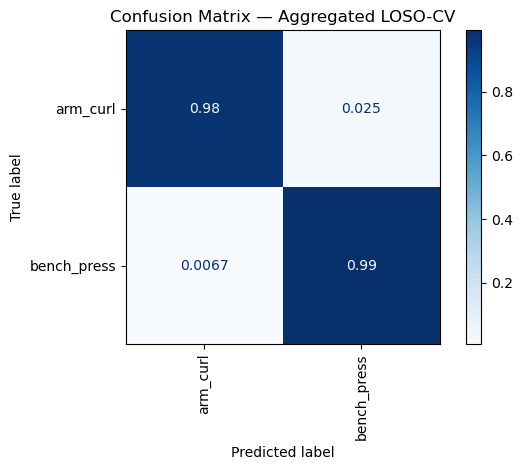

In [167]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Aggregate predictions across all held-out subjects
y_true_all, y_pred_all = aggregate_loso_predictions(per_subject_results)

cm   = confusion_matrix(y_true_all, y_pred_all, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['arm_curl','bench_press'])
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title("Confusion Matrix — Aggregated LOSO-CV")
plt.tight_layout()
plt.show()


In [168]:
print(classification_report(y_true_all, y_pred_all,
                              target_names=['arm_curl','bench_press']))


              precision    recall  f1-score   support

    arm_curl       0.97      0.98      0.97       530
 bench_press       1.00      0.99      0.99      2702

    accuracy                           0.99      3232
   macro avg       0.98      0.98      0.98      3232
weighted avg       0.99      0.99      0.99      3232



---
## 9. Visualize Training Curves

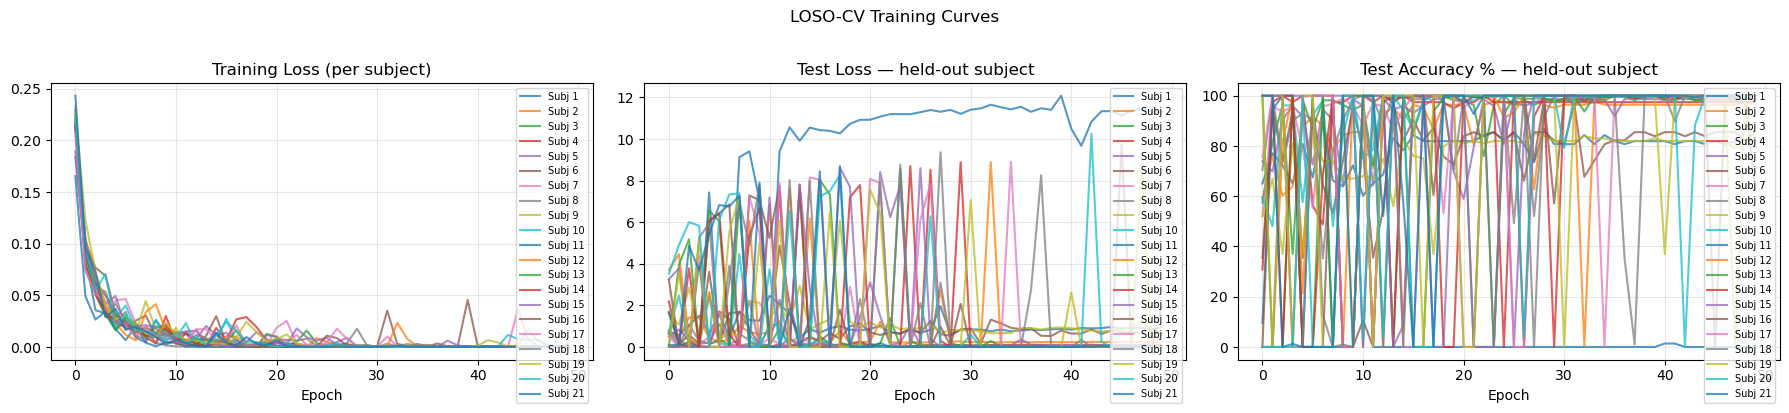

In [169]:
import matplotlib.pyplot as plt

subjects_ordered = sorted(per_subject_results.keys())
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for subj in subjects_ordered:
    hist = per_subject_results[subj]["history"]
    label = f"Subj {subj}"
    axes[0].plot(hist["train_loss"], alpha=0.75, label=label)
    axes[1].plot(hist["val_loss"],   alpha=0.75, label=label)
    axes[2].plot(np.array(hist["val_acc"]) * 100, alpha=0.75, label=label)

axes[0].set_title("Training Loss (per subject)");          axes[0].set_xlabel("Epoch")
axes[1].set_title("Test Loss — held-out subject");         axes[1].set_xlabel("Epoch")
axes[2].set_title("Test Accuracy % — held-out subject");   axes[2].set_xlabel("Epoch")

for ax in axes:
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("LOSO-CV Training Curves", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---
## 10. (Optional) Compare All Baseline Models

In [170]:
# Set to True to run the full comparison (takes a while)
RUN_COMPARISON = False

if RUN_COMPARISON:
    comparison = {}
    for name in ["cnn", "lstm", "bilstm", "gru", "bigru", "cnn_resbigru"]:
        print(f"\n{'#'*60}")
        print(f"  Training: {name}")
        print(f"{'#'*60}")
        comparison[name] = train_evaluate(
            X, y, num_classes=NUM_CLASSES, model_name=name,
            epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
            verbose=False,
        )

    # Summary table
    print(f"\n{'Model':<18} {'Accuracy':>12} {'F1-score':>12} {'Loss':>10}")
    print("─" * 55)
    for name, res in comparison.items():
        acc = np.mean(res['acc']) * 100
        f1 = np.mean(res['f1']) * 100
        loss = np.mean(res['loss'])
        print(f"  {name:<16} {acc:>10.2f}% {f1:>10.2f}% {loss:>10.4f}")

---
## 11. (Optional) Ablation Study

In [171]:
# Set to True to run ablation experiments
RUN_ABLATION = False

if RUN_ABLATION:
    ablation = {}
    for name in ["no_conv", "no_resbigru", "cnn_resbigru"]:
        print(f"\n{'#'*60}")
        print(f"  Ablation: {name}")
        print(f"{'#'*60}")
        ablation[name] = train_evaluate(
            X, y,
            num_classes=NUM_CLASSES, 
            model_name=name,
            epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
            verbose=False,
        )

    print(f"\n{'Variant':<20} {'F1-score':>12}")
    print("─" * 35)
    for name, res in ablation.items():
        f1 = np.mean(res['f1']) * 100
        print(f"  {name:<18} {f1:>10.2f}%")

---
## 12. Save / Load a Trained Model

In [172]:
# Train a single model (not cross-validated) and save it

# Comment this out
X = X_preview
y = y_preview

model = CNNResBiGRU(in_channels=NUM_IMU_CHANNELS,
                    num_classes=NUM_CLASSES).to(DEVICE)

# Quick single train (replace with your full training if needed)
X_t = torch.FloatTensor(X).to(DEVICE)
y_t = torch.LongTensor(y).to(DEVICE)
train_dl = DataLoader(TensorDataset(X_t, y_t), batch_size=64, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

model.train()
for epoch in range(5):  # just a few epochs for demo
    total_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"  Epoch {epoch+1}, Loss: {total_loss / len(train_dl):.4f}")

# Save
torch.save(model.state_dict(), "cnn_resbigru_imu.pt")
print("\nModel saved to cnn_resbigru_imu.pt")

  Epoch 1, Loss: 0.7095
  Epoch 2, Loss: 0.6845
  Epoch 3, Loss: 0.5994
  Epoch 4, Loss: 0.5754
  Epoch 5, Loss: 0.4694

Model saved to cnn_resbigru_imu.pt


In [173]:
# Load for inference
model_loaded = CNNResBiGRU(in_channels=NUM_IMU_CHANNELS,
                           num_classes=NUM_CLASSES).to(DEVICE)
model_loaded.load_state_dict(torch.load("cnn_resbigru_imu.pt",
                                        map_location=DEVICE))
model_loaded.eval()

# Predict on a single window
sample = torch.FloatTensor(X[:1]).to(DEVICE)
with torch.no_grad():
    logits = model_loaded(sample)
    pred = logits.argmax(1).item()
print(f"Predicted class: {pred}")

Predicted class: 1


---
## 13. Test on our collected data

In [ ]:
##### 1. LOAD OurData.csv #####

import pandas as pd

IMU_COLS        = ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]
LABEL_COL       = "target_class"
PARENT_COL      = "parent"
CHILD_COL       = "child"

df_ourdata = pd.read_csv("/Users/Constance/CMU MHCI/WHT/Data/OurData_v3.csv")

df_ourdata['parent'] = df_ourdata['parent'].astype(int)
df_ourdata['child'] = df_ourdata['child'].astype(int)
df_ourdata = df_ourdata.dropna(subset=IMU_COLS).reset_index(drop=True)

# Keep only: (1,1) → class 0, (5,5) → class 1
target_map = {(1, 1): 0,
              (5, 5): 1,
            #   (0, 0): 0,
            #   (1, 2): 0,
            #   (1, 3): 0,
            #   (1, 4): 0,
            #   (5, 6): 0,
            #   (5, 7): 0,
            #   (5, 8): 0,
            #   (5, 9): 0,
            #   (5, 10): 0,
}
df_ourdata[LABEL_COL] = [target_map.get((p, c), np.nan) 
                          for p, c in zip(df_ourdata[PARENT_COL], df_ourdata[CHILD_COL])]
df_ourdata = df_ourdata.dropna(subset=[LABEL_COL]).copy()
df_ourdata[LABEL_COL] = df_ourdata[LABEL_COL].astype(int)

print(f"Loaded OurData: {len(df_ourdata)} samples")
print(f"  Classes: {np.unique(df_ourdata[LABEL_COL]).tolist()}")


PARTICIPANT_COL = "participant"

if PARTICIPANT_COL in df_ourdata.columns:
    df_ourdata[PARTICIPANT_COL] = df_ourdata[PARTICIPANT_COL].astype(int)

    subjects_our     = sorted(df_ourdata[PARTICIPANT_COL].unique())
    subject_data_our = {}
    for subj in subjects_our:
        mask = df_ourdata[PARTICIPANT_COL] == subj
        imu  = df_ourdata.loc[mask, IMU_COLS].values.astype(np.float64)
        labs = df_ourdata.loc[mask, LABEL_COL].values.astype(np.int64)
        subject_data_our[subj] = (imu, labs)

    print(f"Loaded {len(subjects_our)} OurData subjects: {subjects_our}")
    for s, (imu, labs) in subject_data_our.items():
        print(f"  Subject {s:>4}: {imu.shape[0]:>6} samples  "
              f"classes={np.unique(labs).tolist()}")
else:
    print("No 'participant' column in OurData.csv")
    print(f"Loaded OurData rows: {len(df_ourdata)}")
    print(f"Classes: {np.unique(df_ourdata[LABEL_COL]).tolist()}")

Loaded OurData: 9629 samples
  Classes: [0, 1]
Loaded 5 OurData subjects: [np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]
  Subject   22:   2178 samples  classes=[0, 1]
  Subject   23:   2248 samples  classes=[0, 1]
  Subject   24:    892 samples  classes=[1]
  Subject   25:   1931 samples  classes=[0, 1]
  Subject   26:   2380 samples  classes=[0, 1]


In [175]:
##### 2. PREPROCESS OurData (using golden dataset normalization stats) #####

# Create preprocessor and fit ONLY on golden dataset
pp_ourdata = IMUPreprocessor(
    sampling_rate=SAMPLING_RATE,
    window_size_sec=WINDOW_SIZE_SEC,
    overlap=OVERLAP,
)

# Fit normalizer on golden dataset (subject_data_train from earlier)
golden_denoised_all = np.concatenate(
    [pp_ourdata.denoise(subject_data[s][0]) for s in sorted(subject_data.keys())],
    axis=0
)
pp_ourdata.fit_normalize(golden_denoised_all)

# Now preprocess OurData using golden dataset's normalization
imu_ourdata = df_ourdata[IMU_COLS].values.astype(np.float64)
labels_ourdata = df_ourdata[LABEL_COL].values.astype(np.int64)

den_ourdata = pp_ourdata.denoise(imu_ourdata)
norm_ourdata = pp_ourdata.transform_normalize(den_ourdata)
X_ourdata, y_ourdata = pp_ourdata.segment(norm_ourdata, labels_ourdata)

print(f"\nOurData after preprocessing:")
print(f"  Windows : {X_ourdata.shape}  (windows × timesteps × channels)")
print(f"  Labels  : {y_ourdata.shape}  classes={np.unique(y_ourdata).tolist()}")



OurData after preprocessing:
  Windows : (480, 40, 6)  (windows × timesteps × channels)
  Labels  : (480,)  classes=[0, 1]


In [176]:
##### 3. TEST on OurData with ensemble of LOSO models #####

ModelClass = ALL_MODELS["cnn_lstm"]
X_ourdata_t = torch.FloatTensor(X_ourdata).to(DEVICE)

all_logits = []
for i, state in enumerate(loso_results["models"]):
    m = ModelClass(in_channels=NUM_IMU_CHANNELS, num_classes=NUM_CLASSES).to(DEVICE)
    m.load_state_dict(state)
    m.eval()
    with torch.no_grad():
        logits = m(X_ourdata_t).cpu().numpy()
    all_logits.append(logits)

avg_logits = np.mean(np.stack(all_logits, axis=0), axis=0)
y_pred_ourdata = avg_logits.argmax(axis=1)




  OurData Testing Results
  Accuracy : 50.83%
  F1-Score : 50.79%


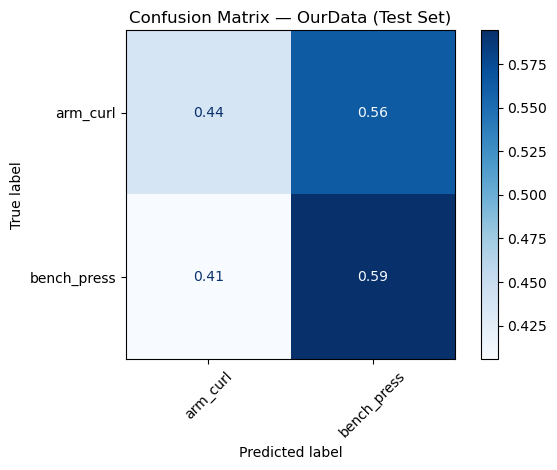


              precision    recall  f1-score   support

    arm_curl       0.57      0.44      0.49       263
 bench_press       0.47      0.59      0.52       217

    accuracy                           0.51       480
   macro avg       0.52      0.52      0.51       480
weighted avg       0.52      0.51      0.51       480



In [177]:
##### 4. RESULTS: Confusion Matrix & Classification Report #####

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

acc = accuracy_score(y_ourdata, y_pred_ourdata)
f1 = f1_score(y_ourdata, y_pred_ourdata, average="macro", zero_division=0)

print(f"\n{'='*50}")
print(f"  OurData Testing Results")
print(f"{'='*50}")
print(f"  Accuracy : {acc*100:.2f}%")
print(f"  F1-Score : {f1*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_ourdata, y_pred_ourdata, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['arm_curl','bench_press'])
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — OurData (Test Set)")
plt.tight_layout()
plt.show()

# Classification Report
print(f"\n{classification_report(y_ourdata, y_pred_ourdata,
                                target_names=['arm_curl','bench_press'],
                                zero_division=0)}")